# 1. Install Dependencies
In this cell, we install the required libraries. We need Ultralytics for training and running the YOLO object detection model, and EasyOCR for reading the text from the detected medicine boxes.

In [1]:
!pip install ultralytics easyocr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 6.1 MB/s eta 0:00:00


## 2. Import Libraries
We import all the necessary modules for computer vision tasks, handling images, and building our detection pipeline.

In [2]:
import cv2
import easyocr
import matplotlib.pyplot as plt
import numpy as np
from ultralytics import YOLO
import os

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


## 3. Model Training
Since the previous trained weights were lost, we need to retrain the YOLO model. We use the YOLOv8 nano model as the base. Make sure the dataset path matches your Kaggle input directory. The trained weights will be saved in the runs/detect/train/weights folder.

In [3]:
# Initialize YOLOv8 nano model
model = YOLO('yolov8n.pt')

# Train the model
# NOTE: Verify if your dataset folder is named 'dataset' or something else in /kaggle/input/
yaml_path = '/kaggle/input/datasets/alinaliaquat/medicines-labels/data.yaml'

results = model.train(
    data=yaml_path,
    epochs=25,
    imgsz=640,
    batch=16,
    project='medicine_detection',
    name='train_run'
)

# The best weights are now saved here:
best_model_path = 'medicine_detection/train_run/weights/best.pt'

Ultralytics 8.4.150 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/alinaliaquat/medicines-labels/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train_run, nbs

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


       2/25      2.55G      1.783      1.968      1.679         16        640: 100% ━━━━━━━━━━━━ 345/345 8.0it/s 43.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 5.9it/s 2.2s
                   all        395        357      0.391      0.521      0.387      0.134

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/25      2.55G      1.793      1.826      1.677         12        640: 100% ━━━━━━━━━━━━ 345/345 8.0it/s 43.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 6.3it/s 2.1s
                   all        395        357      0.463       0.58      0.511      0.203

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/25      2.55G      1.761      1.721      1.667          8        640: 100% ━━━━━━━━━━━━ 345/345 8.1it/s 42.8s
                 Class     Images  Instances      Box

## 4. Initialize OCR and Custom Pipeline
We initialize EasyOCR to read English text. Then, we define a complete pipeline function. This function takes an image, uses YOLO to find where the medicine label is, crops that specific area, and passes it to EasyOCR to read the medicine name.

In [4]:
import cv2
import easyocr
import matplotlib.pyplot as plt
import numpy as np
from ultralytics import YOLO
import os

# Initialize EasyOCR reader
reader = easyocr.Reader(['en'], gpu=True)

# Load our newly trained model
trained_model = YOLO("/kaggle/working/runs/detect/medicine_detection/train_run/weights/best.pt")

def detect_and_read(image_path):
    # Load image
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Step 1: Run YOLO detection
    results = trained_model(img_rgb)
    
    # Loop through detected boxes
    for result in results:
        boxes = result.boxes
        for box in boxes:
            # Get bounding box coordinates
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            
            # Crop the detected medicine area
            cropped_region = img_rgb[y1:y2, x1:x2]
            
            # Step 2: Pass cropped area to OCR
            if cropped_region.size > 0:
                ocr_results = reader.readtext(cropped_region)
                
                detected_text = ""
                if ocr_results:
                    # Get the most confident text result
                    detected_text = ocr_results[0][1]
                else:
                    detected_text = "Unknown"
                
                # --- Premium UI Drawing ---
                
                # 1. Draw thin, sharp bounding box
                cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 255, 0), 2)
                
                # 2. Text properties (Premium look with Duplex font)
                font = cv2.FONT_HERSHEY_DUPLEX
                font_scale = 0.7
                thickness = 1
                text_color = (255, 255, 0) # Bright Yellow in RGB
                
                # 3. Get text size to create a perfect fitting card
                (text_width, text_height), baseline = cv2.getTextSize(detected_text, font, font_scale, thickness)
                
                # 4. Create dark semi-transparent background card
                overlay = img_rgb.copy()
                # Drawing a dark rectangle background (RGB: 30, 30, 30)
                cv2.rectangle(overlay, (x1, y1 - text_height - 15), (x1 + text_width + 10, y1), (30, 30, 30), -1)
                
                # Apply 70% opacity to the dark card
                cv2.addWeighted(overlay, 0.7, img_rgb, 0.3, 0, img_rgb)
                
                # 5. Put bright text over the dark card with Anti-Aliasing for smoothness
                cv2.putText(img_rgb, detected_text, (x1 + 5, y1 - 7), 
                            font, font_scale, text_color, thickness, cv2.LINE_AA)
                
    return img_rgb

## 5. Test on a Sample Image
We select a sample image from our test dataset and run our complete pipeline on it to see both the bounding box and the extracted medicine name.


0: 640x640 1 medicine, 7.2ms
Speed: 2.8ms preprocess, 7.2ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


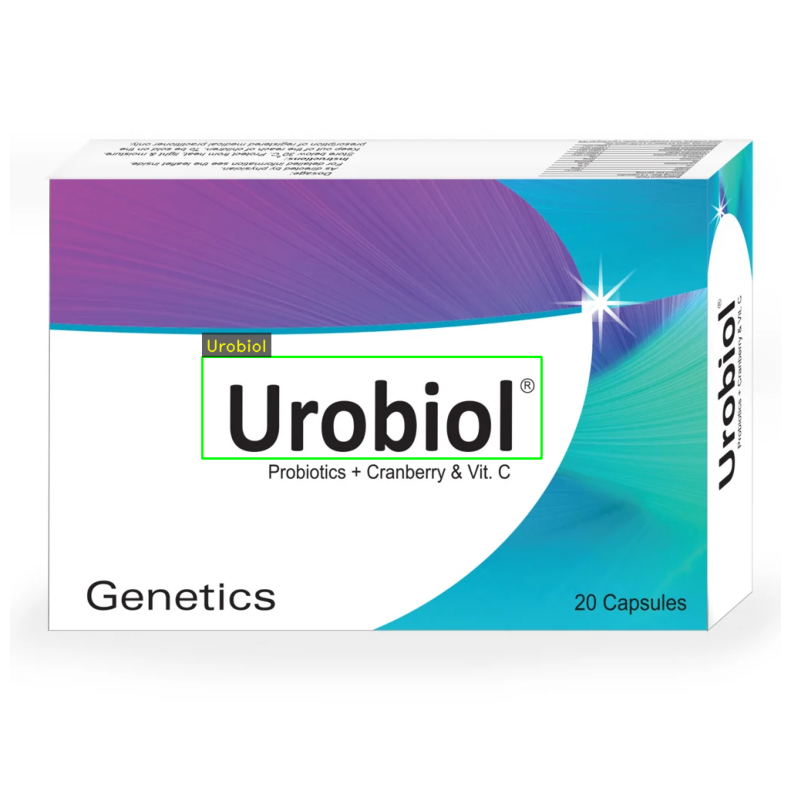

In [5]:
# Replace this path with an actual test image path from your dataset
sample_image = '/kaggle/input/datasets/alinaliaquat/medicine-img2/urobiol.png'

if os.path.exists(sample_image):
    output_img = detect_and_read(sample_image)
    
    plt.figure(figsize=(14, 10))
    plt.imshow(output_img)
    plt.axis('off')
    plt.show()
else:
    print("Please provide a valid test image path.")

## 6. Process Video Files 
This cell processes a video frame by frame. It applies YOLO for detection and EasyOCR for text reading on each frame, saving the output as a new video file.

In [6]:
def process_video(input_video_path, output_video_path):
    cap = cv2.VideoCapture(input_video_path)
    
    # Get video properties
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    
    # Define video writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
            
        # YOLO Detection
        results = trained_model(frame)
        
        for result in results:
            boxes = result.boxes
            for box in boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                
                cropped_region = frame[y1:y2, x1:x2]
                
                # OCR extraction
                if cropped_region.size > 0:
                    ocr_results = reader.readtext(cropped_region)
                    
                    if ocr_results:
                        detected_text = ocr_results[0][1]
                    else:
                        detected_text = "Medicine"
                    
                    # UI Properties
                    font = cv2.FONT_HERSHEY_DUPLEX
                    font_scale = 0.7
                    thickness = 1
                    text_color = (0, 255, 255) # Bright Yellow in BGR
                    box_fill_color = (0, 200, 0) # Green fill for bounding box
                    box_border_color = (0, 255, 0) # Bright Green border
                    
                    (text_width, text_height), _ = cv2.getTextSize(detected_text, font, font_scale, thickness)
                    
                    # Create an overlay for transparency effects
                    overlay = frame.copy()
                    
                    # 1. Draw transparent fill inside the bounding box
                    cv2.rectangle(overlay, (x1, y1), (x2, y2), box_fill_color, -1)
                    
                    # 2. Draw dark card for the text background
                    cv2.rectangle(overlay, (x1, y1 - text_height - 15), (x1 + text_width + 10, y1), (30, 30, 30), -1)
                    
                    # Apply 40% opacity to the overlay (fill and card)
                    cv2.addWeighted(overlay, 0.4, frame, 0.6, 0, frame)
                    
                    # 3. Draw sharp, solid border for bounding box
                    cv2.rectangle(frame, (x1, y1), (x2, y2), box_border_color, 2)
                    
                    # 4. Put bright text over the card with Anti-Aliasing
                    cv2.putText(frame, detected_text, (x1 + 5, y1 - 7), 
                                font, font_scale, text_color, thickness, cv2.LINE_AA)
        
        out.write(frame)
        
    cap.release()
    out.release()
    print("Video processing complete. Saved to:", output_video_path)

# Uncomment below lines and add your video path to run
input_vid  = '/kaggle/input/datasets/alinaliaquat/video-1/v1.mp4'
output_vid = '/kaggle/working/m1.mp4'
process_video(input_vid, output_vid)


0: 384x640 (no detections), 38.5ms
Speed: 1.7ms preprocess, 38.5ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 5.6ms
Speed: 1.7ms preprocess, 5.6ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 5.5ms
Speed: 1.8ms preprocess, 5.5ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 5.7ms
Speed: 1.5ms preprocess, 5.7ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 5.6ms
Speed: 1.7ms preprocess, 5.6ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 medicine, 5.7ms
Speed: 1.4ms preprocess, 5.7ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 medicine, 5.6ms
Speed: 1.7ms preprocess, 5.6ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 medicine, 5.6ms
Speed: 1.4ms preprocess, 5.6ms inference, 1.1ms postprocess p